<a href="https://colab.research.google.com/github/Mijdilev/Mental_Health_Survey_Unsupervised_Machine_Learning/blob/main/Survey_Analysis_UML_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_colwidth', 60)
pd.set_option('display.width', 120)

df = pd.read_csv('survey.csv')

Splitter = '-' * 70

def section(title):
    print(f'\n{Splitter}')
    print(f'  {title}')
    print(Splitter)


section('1. DATASET DIMENSIONS')
print(f'  Rows      : {df.shape[0]}')
print(f'  Columns   : {df.shape[1]}')
print(f'  Numeric   : {df.select_dtypes(include="number").shape[1]}')
print(f'  Text      : {df.select_dtypes(include="object").shape[1]}')


section('2. MISSING VALUES  (columns with any missing, sorted)')
miss = (df.isnull().mean() * 100).sort_values(ascending=False)
miss = miss[miss > 0].rename('missing_%').round(1)
miss.index = [c[:60] + ('…' if len(c) > 60 else '') for c in miss.index]
print(miss.to_string())

section('3. AGE')
age = df['What is your age?']
print(age.describe().round(1).to_string())
outliers = age[(age < 18) | (age > 70)].dropna()
print(f'\n  Implausible values (< 18 or > 70): {len(outliers)}')
print(f'  Values: {sorted(outliers.tolist())}')

section('4. GENDER  (raw — illustrating non-standardised free-text input)')
gender_counts = df['What is your gender?'].value_counts(dropna=False)
print(f'  Unique variants : {df["What is your gender?"].nunique()}')
print(f'  Missing         : {df["What is your gender?"].isnull().sum()}')
print(f'\n  Top 15 variants (out of 70+):')
print(gender_counts.head(15).to_string())
print('  ... (remaining variants each appear 1-4 times)')


section('5. DEMOGRAPHICS SUMMARY')

print('\n  Top 10 countries:')
print(df['What country do you live in?'].value_counts().head(10).to_string())

print('\n  Self-employed:')
print(df['Are you self-employed?'].value_counts().to_string())

print('\n  Company size:')
print(df['How many employees does your company or organization have?']
      .value_counts(dropna=False).to_string())

print('\n  Remote work:')
print(df['Do you work remotely?'].value_counts().to_string())


section('6. MENTAL HEALTH PREVALENCE')

prev_cols = {
    'Currently has MH disorder':
        'Do you currently have a mental health disorder?',
    'Past MH disorder':
        'Have you had a mental health disorder in the past?',
    'Family history of MH illness':
        'Do you have a family history of mental illness?',
    'Ever sought professional treatment':
        'Have you ever sought treatment for a mental health issue from a mental health professional?',
    'Professionally diagnosed':
        'Have you been diagnosed with a mental health condition by a medical professional?',
}

rows = {}
for label, col in prev_cols.items():
    vc = df[col].value_counts(normalize=True).mul(100).round(1)
    # normalize 1/0 integer encoding to Yes/No
    vc.index = [('Yes' if str(i) in ['1', '1.0']
                 else 'No' if str(i) in ['0', '0.0']
                 else i) for i in vc.index]
    rows[label] = vc

summary = pd.DataFrame(rows).T
# keep a consistent column order
for col in ['Yes', 'Maybe', "I don't know", 'No']:
    if col not in summary.columns:
        summary[col] = np.nan
summary = summary[['Yes', 'Maybe', "I don't know", 'No']].fillna(0)
print(summary.to_string())

section('7. WORKPLACE OPENNESS & STIGMA  (%)')

open_cols = {
    'Fears consequences (employer)':
        'Do you think that discussing a mental health disorder with your employer would have negative consequences?',
    'Comfortable with supervisor':
        "Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?",
    'Comfortable with coworkers':
        'Would you feel comfortable discussing a mental health disorder with your coworkers?',
    'Would raise MH in interview':
        'Would you bring up a mental health issue with a potential employer in an interview?',
    'MH disclosure hurts career':
        'Do you feel that being identified as a person with a mental health issue would hurt your career?',
}

rows = {}
for label, col in open_cols.items():
    vc = df[col].value_counts(normalize=True).mul(100).round(1)
    # merge "Yes, I think it would" / "Yes, it has" to Yes  etc.
    merged = {}
    for k, v in vc.items():
        key = ('Yes'   if str(k).startswith('Yes')
               else 'No'    if str(k).startswith('No')
               else str(k))
        merged[key] = merged.get(key, 0) + v
    rows[label] = merged

summary2 = pd.DataFrame(rows).T.fillna(0).round(1)
for col in ['Yes', 'Maybe', 'No']:
    if col not in summary2.columns:
        summary2[col] = 0.0
print(summary2[['Yes', 'Maybe', 'No']].to_string())


----------------------------------------------------------------------
  1. DATASET DIMENSIONS
----------------------------------------------------------------------
  Rows      : 1433
  Columns   : 63
  Numeric   : 7
  Text      : 56

----------------------------------------------------------------------
  2. MISSING VALUES  (columns with any missing, sorted)
----------------------------------------------------------------------
If you have revealed a mental health issue to a client or bu…    90.0
If yes, what percentage of your work time (time performing p…    85.8
Is your primary role within your company related to tech/IT?     81.6
Do you have medical coverage (private insurance or state-pro…    80.0
If you have been diagnosed or treated for a mental health di…    80.0
If you have been diagnosed or treated for a mental health di…    80.0
If you have revealed a mental health issue to a coworker or …    80.0
Do you know local or online resources to seek help for a men…    80.0
Do yo

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture


# Load the original dataset
df = pd.read_csv('survey.csv')
print(f'Loaded:                    {df.shape[1]:>3} columns')

# Dropping column with less than 50% answers
def drop_bad_columns(df):
    miss  = df.isnull().mean()
    drop  = miss[miss > 0.5].index
    free  = [c for c in df if c.startswith("Why or why not")]
    state = [c for c in df if "US state" in c]
    return df.drop(columns=set(drop) | set(free) | set(state))

df = drop_bad_columns(df)
# report on after-step column number
print(f'After column dropping:     {df.shape[1]:>3}')

# Fixing Excel's changes od some Company Sizes to dates
company_col = 'How many employees does your company or organization have?'
df[company_col] = df[company_col].replace({
    'Jan-05': '1-5', '05-Jan': '1-5', 'Jun-25': '6-25', '25-Jun': '6-25'
}).fillna('Self-employed')

age_col = 'What is your age?'
age_median = df.loc[(df[age_col] >= 18) & (df[age_col] <= 70), age_col].median()
df[age_col] = df[age_col].where((df[age_col] >= 18) & (df[age_col] <= 70), age_median)

# Normalizing gender column
def clean_gender(x):
    v = str(x).strip().lower()
    if v in ["male", "m", "man", "cis male", "cis man", "malr", "mail", "male "]:
        return "Male"
    if v in ["female", "f", "woman", "cis female", "cis woman", "femake", "femail", "female "]:
        return "Female"
    return "Other"

df["gender_clean"] = df["What is your gender?"].apply(clean_gender)
df.drop(columns=["What is your gender?"], inplace=True)

# Encoding Workposition column
pos_col = 'Which of the following best describes your work position?'
if pos_col in df.columns:
    all_roles = set()
    for val in df[pos_col].dropna():
        for role in str(val).split('|'):
            all_roles.add(role.strip())
    for role in sorted(all_roles):
        col_name = 'role_' + role.replace(' ', '_').replace('/', '_')
        df[col_name] = df[pos_col].apply(lambda x: 1 if role in str(x) else 0)
    df.drop(columns=[pos_col], inplace=True)
print(f'After basic cleaning:      {df.shape[1]:>3} columns')

# Missing value imputation
for col in df.columns[df.isnull().any()]:
    mode_vals = df[col].mode()
    if len(mode_vals) == 0:
        df.drop(columns=[col], inplace=True)
        continue
    df[col + "_missing"] = df[col].isnull().astype(int)
    df[col] = df[col].fillna(mode_vals[0])
print(f'After imputation (+flags): {df.shape[1]:>3} columns  (missingness indicators added)')

#Ordinal columns encoding
ordinals = {


    company_col: {
        'Self-employed': 0, '1-5': 1, '6-25': 2, '26-100': 3,
        '100-500': 4, '500-1000': 5, 'More than 1000': 6
    },
    'Do you work remotely?': {
        'Never': 0, 'Sometimes': 1, 'Always': 2
    },

    'Does your employer provide mental health benefits as part of healthcare coverage?': {
        'No': 0, 'Not eligible for coverage / N/A': 0,
        "I don't know": 1, 'Yes': 2
    },
    'Do you know the options for mental health care available under your employer-provided coverage?': {
        'No': 0, 'I am not sure': 1, 'Yes': 2
    },
    'Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?': {
        'No': 0, "I don't know": 1, 'Yes': 2
    },
    'If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:': {
        'Very difficult': 0, 'Somewhat difficult': 1,
        'Neither easy nor difficult': 2, "I don't know": 2,
        'Somewhat easy': 3, 'Very easy': 4
    },

    'Have your previous employers provided mental health benefits?': {
        'No, none did': 0, "I don't know": 1, 'Some did': 2, 'Yes, they all did': 3
    },
    'Were you aware of the options for mental health care provided by your previous employers?': {
        'N/A (not currently aware)': 0, 'No, I only became aware later': 1,
        'I was aware of some': 2, 'Yes, I was aware of all of them': 3
    },
    'Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?': {
        'None did': 0, "I don't know": 1, 'Some did': 2, 'Yes, they all did': 3
    },
    'Did your previous employers provide resources to learn more about mental health issues and how to seek help?': {
        'None did': 0, 'Some did': 1, 'Yes, they all did': 2
    },
    'Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?': {
        'No': 0, "I don't know": 1, 'Sometimes': 2, 'Yes, always': 3
    },
    'Do you think that discussing a mental health disorder with previous employers would have negative consequences?': {
        'Yes, all of them': 0, 'Some of them': 1,
        "I don't know": 1, 'None of them': 2
    },
    'Do you think that discussing a physical health issue with previous employers would have negative consequences?': {
        'Yes, all of them': 0, 'Some of them': 1, 'None of them': 2
    },
    'Would you have been willing to discuss a mental health issue with your previous co-workers?': {
        'No, at none of my previous employers': 0,
        'Some of my previous employers': 1,
        'Yes, at all of my previous employers': 2
    },
    'Would you have been willing to discuss a mental health issue with your direct supervisor(s)?': {
        'No, at none of my previous employers': 0,
        "I don't know": 1, 'Some of my previous employers': 1,
        'Yes, at all of my previous employers': 2
    },
    'Did you feel that your previous employers took mental health as seriously as physical health?': {
        'None did': 0, "I don't know": 1, 'Some did': 2, 'Yes, they all did': 3
    },
    'Did you hear of or observe negative consequences for co-workers with mental health issues in your previous workplaces?': {
        'None of them': 0, 'Some of them': 1, 'Yes, all of them': 2
    },

    'Do you feel that being identified as a person with a mental health issue would hurt your career?': {
        'No, it has not': 0, "No, I don't think it would": 0,
        'Maybe': 1, 'Yes, I think it would': 2, 'Yes, it has': 2
    },
    'Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue?': {
        'No, they do not': 0, "No, I don't think they would": 0,
        'Maybe': 1, 'Yes, I think they would': 2, 'Yes, they do': 2
    },
    'How willing would you be to share with friends and family that you have a mental illness?': {
        'Not applicable to me (I do not have a mental illness)': 0,
        'Not open at all': 1, 'Somewhat not open': 2,
        'Neutral': 3, 'Somewhat open': 4, 'Very open': 5
    },
    'Have you observed or experienced an unsupportive or badly handled response to a mental health issue in your current or previous workplace?': {
        'No': 0, 'Maybe/Not sure': 1,
        'Yes, I observed': 2, 'Yes, I experienced': 3
    },

    'If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?': {
        'Not applicable to me': 0, 'Never': 1, 'Rarely': 2,
        'Sometimes': 3, 'Often': 4
    },
    'If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?': {
        'Not applicable to me': 0, 'Never': 1, 'Rarely': 2,
        'Sometimes': 3, 'Often': 4
    },
}

for col, map_ in ordinals.items():
    if col in df.columns:
        df[col] = df[col].map(map_)
        df[col] = df[col].fillna(df[col].median())

# Yes/No/Maybe encoding
def yes_no(x):
    v = str(x).strip().lower()
    if v == 'yes':   return 1.0
    if v == 'no':    return 0.0
    return 0.5

for col in df.select_dtypes('object').columns:
    vals = set(df[col].str.strip().str.lower().unique())
    if vals <= {'yes', 'no', 'maybe', 'not sure', 'maybe/not sure'}:
        df[col] = df[col].apply(yes_no)

# Nominal encoding
df = pd.get_dummies(df, columns=['gender_clean'], prefix='gender', drop_first=False)

country_cols = ['What country do you live in?', 'What country do you work in?']
for col in country_cols:
    if col in df.columns:
        freq = df[col].value_counts(normalize=True)
        df[col] = df[col].map(freq)
print(f'After encoding:            {df.shape[1]:>3} columns  (ordinal + yes/no + dummies + freq)')

# Feature selection
df = df.apply(pd.to_numeric, errors='coerce').fillna(0)
bool_cols = df.select_dtypes('bool').columns
df[bool_cols] = df[bool_cols].astype(int)

n_before_var = df.shape[1]
low_var = df.columns[df.var() <= 0.01].tolist()
df = df.loc[:, df.var() > 0.01]
print(f"\n--- Variance filter: {n_before_var} → {df.shape[1]} features "
      f"({len(low_var)} removed) ---")
for c in low_var:
    print(f"  removed (low variance): {c}")

corr  = df.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), 1).astype(bool))

# Reports on correlated columns
drop_pairs = {}
for c in upper.columns:
    partners = upper.index[upper[c] > 0.85].tolist()
    if partners:
        drop_pairs[c] = (partners[0], round(upper.loc[partners[0], c], 2))
drop = list(drop_pairs.keys())
df   = df.drop(columns=drop)

print(f"\n--- Correlation filter (r > 0.85): {df.shape[1] + len(drop)} → {df.shape[1]} features "
      f"({len(drop)} removed) ---")
for c, (partner, r) in drop_pairs.items():
    print(f"  removed: {c[:55]}")
    print(f"    > correlated with: {partner[:55]}  (r={r})")

# Scaling
binary = [c for c in df.columns if df[c].nunique() <= 2]
scale  = [c for c in df.columns if c not in binary]

scaler    = RobustScaler()
df[scale] = scaler.fit_transform(df[scale])


# PCA for GMM clustering
pca_full = PCA().fit(df)
n = int(np.argmax(np.cumsum(pca_full.explained_variance_ratio_) >= 0.85) + 1)
X = PCA(n_components=n, random_state=42).fit_transform(df)
print(f"After PCA:                 {n:>3} components  (85% variance threshold)")


# GMM clustering
bic_scores = []
aic_scores = []
k_range    = range(2, 9)

for k in k_range:
    gmm = GaussianMixture(n_components=k, n_init=5, random_state=42)
    gmm.fit(X)
    bic_scores.append(gmm.bic(X))
    aic_scores.append(gmm.aic(X))

best_k = k_range[int(np.argmin(bic_scores))]

test_labels = GaussianMixture(n_components=best_k, n_init=5, random_state=42).fit_predict(X)
if pd.Series(test_labels).value_counts().max() / len(test_labels) > 0.75 and best_k == 2:
    best_k = max(k_range[int(np.argmin(aic_scores))], 3)
print(f"BIC suggested {np.argmin(bic_scores)} — using AIC: k={best_k}")

model  = GaussianMixture(n_components=best_k, n_init=10, random_state=42)
labels = model.fit_predict(X)
df["cluster"] = labels


df.to_csv('survey_clustered_v3.csv', index=False)
print(f"Clusters (k={best_k}):", df.cluster.value_counts().sort_index().to_dict())

Loaded:                     63 columns
After column dropping:      46
After basic cleaning:       57 columns
After imputation (+flags):  82 columns  (missingness indicators added)
After encoding:             84 columns  (ordinal + yes/no + dummies + freq)

--- Variance filter: 84 → 79 features (5 removed) ---
  removed (low variance): Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?
  removed (low variance): Does your employer offer resources to learn more about mental health concerns and options for seeking help?
  removed (low variance): Do you feel that your employer takes mental health as seriously as physical health?
  removed (low variance): Do you have a family history of mental illness?
  removed (low variance): role_HR

--- Correlation filter (r > 0.85): 79 → 54 features (25 removed) ---
  removed: What country do you work in?
    > correlated with: What country do you live in?  (r=0.97)
  re

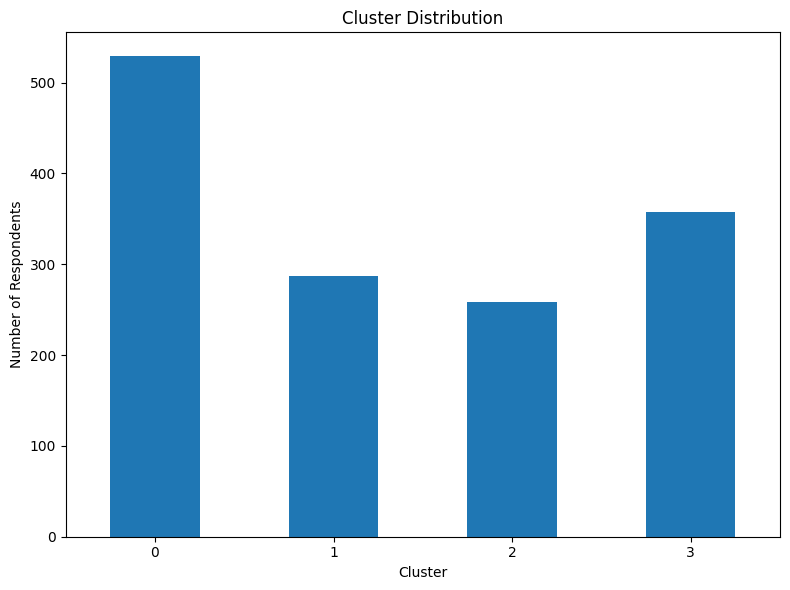

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

clustered_df = pd.read_csv('survey_clustered_v3.csv')

# Count the occurrences of each cluster
cluster_counts = clustered_df['cluster'].value_counts().sort_index()

# plot the result
plt.figure(figsize=(8, 6))
cluster_counts.plot(kind='bar')
plt.xlabel('Cluster')
plt.ylabel('Number of Respondents')
plt.title('Cluster Distribution')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



In [4]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

raw    = pd.read_csv('survey.csv')
labels = pd.read_csv('survey_clustered_v3.csv')['cluster']
df     = raw.assign(cluster=labels)
sizes  = df['cluster'].value_counts().sort_index()

# Questions and "positive" response type
QUESTIONS = [
    # label                           column                                                    positive values
    ('Self-employed',                 'Are you self-employed?',                                 [1]),
    ('Mean age',                      'What is your age?',                                      None),   # None = mean
    ('Past MH disorder ("Yes" answers)',              'Have you had a mental health disorder in the past?',     ['Yes']),
    ('Sought treatment ("Positive answers")' ,             'Have you ever sought treatment for a mental health issue from a mental health professional?', [1]),
    ('Comfortable w/ supervisor ("Yes" answers)',     'Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?', ['Yes']),
    ('Comfortable w/ coworkers ("Yes" answers)',      'Would you feel comfortable discussing a mental health disorder with your coworkers?', ['Yes']),
    ('Fears employer consequences ("Yes" answers)',   'Do you think that discussing a mental health disorder with your employer would have negative consequences?', ['Yes']),
    ('MH hurts career (Positive answers)',               'Do you feel that being identified as a person with a mental health issue would hurt your career?', ['Yes, I think it would', 'Yes, it has']),
    ('Coworkers view negatively (Positive answers)',     'Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue?', ['Yes, I think they would', 'Yes, they do']),
    ('Would raise MH topic in the interview ("Yes" answers)', 'Would you be willing to bring up a physical health issue with a potential employer in an interview?', ['Yes'])
]


rows = {}
for label, col, positive in QUESTIONS:
    if positive is None:
        stat = df.groupby('cluster')[col].mean().round(1)
        rows[label] = stat
    else:
        stat = df.groupby('cluster')[col].apply(
            lambda x: round(x.isin(positive).mean() * 100, 1)
        )
        rows[label] = stat

table = pd.DataFrame(rows).T
table.columns = [f'C{c}  (n={sizes[c]})' for c in table.columns]

print(table.to_string())

COLORS  = ['#2D6A4F', '#457B9D', '#E76F51', '#E9C46A']
n_cols  = table.shape[1]
n_rows  = table.shape[0]

fig, ax = plt.subplots(figsize=(10, 0.45 * n_rows + 1.5))
ax.axis('off')

col_labels = list(table.columns)
row_labels  = list(table.index)
cell_values = table.values


cell_colors = []
for i, row in enumerate(cell_values):
    row_colors = ['#FAFAF8'] * n_cols
    if row_labels[i] not in ('Mean age', 'Self-employed'):
        max_idx = int(np.argmax(row))
        row_colors[max_idx] = '#D4EDDA'   # light green = highest
        min_idx = int(np.argmin(row))
        row_colors[min_idx] = '#FDE8E4'   # light red = lowest
    cell_colors.append(row_colors)

tbl = ax.table(
    cellText=[[f'{v:.1f}' for v in row] for row in cell_values],
    rowLabels=row_labels,
    colLabels=col_labels,
    cellColours=cell_colors,
    loc='center',
    cellLoc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.6)

for j, color in enumerate(COLORS[:n_cols]):
    tbl[0, j].set_facecolor(color)
    tbl[0, j].set_text_props(color='white', fontweight='bold')

for i in range(n_rows):
    tbl[i + 1, -1].set_text_props(ha='left', fontweight='bold', color='#1A1A2E')
    tbl[i + 1, -1].set_facecolor('#F0F0F0')

fig.tight_layout()
fig.savefig('cluster_profiles_table.png',
            dpi=150, bbox_inches='tight')
plt.close()
print('\nSaved: cluster_profiles_table.png')

                                                       C0  (n=529)  C1  (n=287)  C2  (n=259)  C3  (n=358)
Self-employed                                                  0.0        100.0          0.0          0.0
Mean age                                                      32.7         36.8         35.2         33.9
Past MH disorder ("Yes" answers)                              43.7         53.3         62.9         52.8
Sought treatment ("Positive answers")                         49.1         63.4         69.5         60.6
Comfortable w/ supervisor ("Yes" answers)                     36.5          0.0         19.7         51.4
Comfortable w/ coworkers ("Yes" answers)                      22.3          0.0         10.8         36.0
Fears employer consequences ("Yes" answers)                   16.1          0.0         39.8          9.2
MH hurts career (Positive answers)                            40.8         48.8        100.0         14.8
Coworkers view negatively (Positive answers)  